In [1]:
# =============================================================
# 악기 오디오 파일 분류 실습 (FULL PIPELINE / 전문 주석 강화 버전)
# =============================================================

# 데이터 구조:
# ../data/audio/
#           cello/
#                  *.mp3
#           flute/
#                  *.mp3
#           oboe/
#                  *.mp3
#           sax/
#                  *.mp3
#           trumpet/
#                  *.mp3
#           viola/
#                  *.mp3


# 실습 목표
#  1) 오디오 파일 읽기
#  2) wave plot 시각화
#  3) FFT 시각화
#  4) Spectrogram 생성 및 이미지 저장
#  5) CNN 분류 모델 학습
#  6) 성능 평가
#  7) 신규 오디오 예측 (절대경로 입력)
#  8) 예측 결과 시각화
#  9) 에러 방지 로직 반영


In [2]:
#=============================================================
# 1. 필수 라이브러리 import
#=============================================================

import os,glob, random, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

# 오디오 로딩, STFT, mel spectrogram, dB 변환 등 오디오 DSP 전처리 핵심 라이브러리
import librosa

# librosa 기반 파형/ 스펙트로그램 표시용 보조 시각화 모듈
import librosa.display

# 저장된 spectrogram 이미지를 읽고, RGB 변환 및 크기 통일에 사용
from PIL import Image
from jupyter_core.version import pattern
from jupyter_server.transutils import base_dir

from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers,models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

import warnings
warnings.filterwarnings("ignore")

In [3]:
#=============================================================
# 2. 기본 경로 및 전역 하이퍼파라미터 설정
#=============================================================

BASE_DIR = "../data/audio"
INSTRUMENTS_DIR = BASE_DIR + "/instruments"
SPEC_DIR = BASE_DIR + "/spectrogram_data" #오디오를 이미지로 변환해 저장할 루트 폴더
SPLIT_DIR = BASE_DIR + "/spectrogram_split" #CNN 학습용으로 train/val/test 구조로 나누어 저장 루트 폴더

BEST_MODEL_PATH = BASE_DIR + '/best_instrument_cnn_model.keras' # 최종 핛브 모델 저장
TEMP_PREDICT_IMAGE_PATH = BASE_DIR + '/temp_predict_spectrogram.png' #신규 예측시 임시로 스펙트로그램 이미지를 저장할 경로

CLASSES = ["cello", "flute","oboe","sax", "trumpet","viola"] #분류 대상 클래스는 폴더명과 일치

# CNN 입력 이미지 높이
IMG_HEIGHT = 224

# CNN 입력 이미지 너비
IMG_WIDTH = 224

# signal processing 파라미터 설정
SR = 22050 # 샘플링 주파수
DURATION = 1.5 # 오디오 길이 (초단위)
SAMPLES_PER_TRACK = SR * DURATION # 1개 오디오 샘플 당 기대되는 총 샘플 수
N_FFT = 4096 # 멜 스펙트로그램 생성 시, 사용할 FFT 윈도우 길이
HOP_LENGTH = 128 # 프레임 간 hop 크기 (값이 작을수록 시간 해상도 증가)
N_MELS = 126 #192 # mel filter bank 개수 (너무 작으면 정보 깨지고, 너무 크면 이미지 복잡해짐)

BATCH_SIZE = 16 # 미니배치 크기
EPOCHS = 25 # 반복 학습 수

In [4]:
# ------------------------------------------------------------
# 3. 유효성 검사 및 공통 유틸리티 함수
# ------------------------------------------------------------

def ensure_directory_exists(dir_path):
    """
    지정한 디렉토리가 존재하지 않으면 생성
    """
    os.makedirs(dir_path, exist_ok=True)


def validate_audio_directory_structure(audio_dir, classes):
    """
    audio 폴더와 클래스별 하위 폴더가 존재하는지 확인
    """
    if not os.path.exists(audio_dir):
        raise FileNotFoundError(f"[오류] audio 루트 폴더를 찾을 수 없습니다: {audio_dir}")

    for cls in classes:
        class_dir = os.path.join(audio_dir, cls)
        if not os.path.exists(class_dir):
            raise FileNotFoundError(f"[오류] 클래스 폴더가 없습니다: {class_dir}")


def count_audio_files(audio_dir, classes, extension="*.mp3"):
    """
    클래스별 오디오 파일 개수를 집계하여 dict 형태로 반환
    """
    counts = {}
    for cls in classes:
        pattern = os.path.join(audio_dir, cls, extension)
        counts[cls] = len(glob.glob(pattern))
    return counts


def validate_minimum_files_per_class(file_counts, minimum_count=3):
    """
    각 클래스에 최소 개수 이상의 파일이 존재하는지 검증
    """
    for cls, count in file_counts.items():
        if count < minimum_count:
            raise ValueError(
                f"[오류] 클래스 '{cls}'의 파일 수가 너무 적습니다. "
                f"최소 {minimum_count}개 이상 필요하지만 현재 {count}개입니다."
            )


def safe_remove_path(path):
    """
    파일 또는 디렉토리가 존재할 때만 삭제
    """
    if os.path.isdir(path):
        shutil.rmtree(path)
    elif os.path.isfile(path):
        os.remove(path)


def print_section_title(title):
    """
    노트북에서 섹션 구분이 명확하게 보이도록 제목 출력
    """
    print("\n" + "=" * 60)
    print(title)
    print("=" * 60)


데이터 폴더 및 파일 개수 확인
원본 오디오 루트 경로 :  ../data/audio/instruments
스펙트로그램 저장 경로 :  ../data/audio/spectrogram_data
분할 데이터 저장 경로 :  ../data/audio/spectrogram_split

     Class  Count
0    cello    100
1    flute    100
2     oboe    100
3      sax    100
4  trumpet    100
5    viola    100


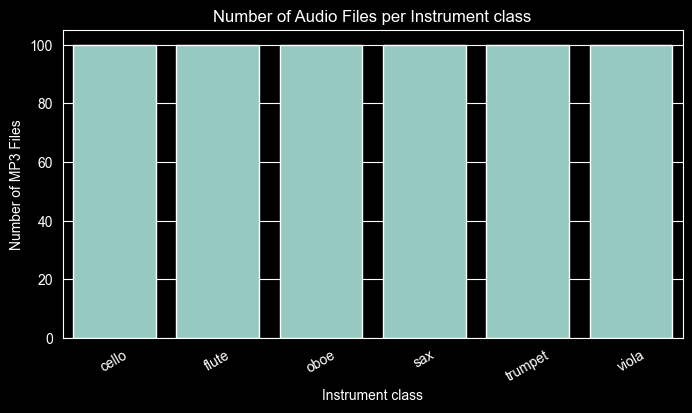

In [5]:
#=============================================================
# 4. 데이터 폴더 구조 및 파일 개수 확인
#=============================================================

# audio 폴더와 클래스별 하위 폴더가 실제로 존재한느지 검증
validate_audio_directory_structure(INSTRUMENTS_DIR, CLASSES)

# 클래스 별 mp3 개수를 집계
file_counts = count_audio_files(INSTRUMENTS_DIR, CLASSES, extension="*.mp3")

# 각 클래스가 최소한의 샘플 수를 갖는지 확인
validate_minimum_files_per_class(file_counts, minimum_count=3)

# 집계 결과를 데이터프레임으로 변환
file_counts_df = pd.DataFrame(list(file_counts.items()), columns=["Class","Count"])

# 현재 데이터 구성 상황을 출력
print_section_title("데이터 폴더 및 파일 개수 확인")
print("원본 오디오 루트 경로 : ", INSTRUMENTS_DIR)
print("스펙트로그램 저장 경로 : ", SPEC_DIR)
print("분할 데이터 저장 경로 : ", SPLIT_DIR)
print()
print(file_counts_df)

# 클래스별 데이터 불균형 여부를 시각적으로 확인
plt.figure(figsize=(8,4))
sns.barplot(data = file_counts_df, x="Class", y="Count")
plt.title("Number of Audio Files per Instrument class")
plt.xlabel("Instrument class")
plt.ylabel("Number of MP3 Files")
plt.xticks(rotation=30)
plt.show()

In [6]:
# ------------------------------------------------------------
# 5. 오디오 로드 함수 정의
# ------------------------------------------------------------
def load_audio_file(file_path, sr=SR, duration=DURATION):
    """
    오디오 파일을 모노 신호로 읽고, 지정 길이로 고정한다.

    설계 의도:
    - 모델 입력 일관성을 위해 모든 오디오 길이를 동일하게 맞춘다.
    - 너무 짧은 파일은 zero-padding한다.
    - 너무 긴 파일은 앞부분을 사용한다.
    - 실습/강의 환경에서 mp3 코덱 또는 파일 경로 문제를 조기에 감지할 수 있도록 예외를 명확히 전달한다.
    """

    # 입력 경로가 문자열인지 확인한다.
    if not isinstance(file_path, str):
        raise TypeError(f"[오류] file_path는 문자열이어야 합니다. 현재 타입: {type(file_path)}")

    # 실제 파일 존재 여부를 먼저 확인한다.
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"[오류] 오디오 파일이 존재하지 않습니다: {file_path}")

    # 파일 확장자를 확인한다. 이 실습은 mp3를 기본으로 가정하지만 wav 등으로 확장 가능하다.
    valid_exts = [".mp3", ".wav", ".flac", ".ogg", ".m4a"]
    ext = os.path.splitext(file_path)[1].lower()
    if ext not in valid_exts:
        raise ValueError(f"[오류] 지원하지 않는 오디오 확장자입니다: {ext}")

    try:
        # mono=True는 스테레오 입력을 단일 채널로 평균/변환하여 처리 일관성을 확보한다.
        y, sr = librosa.load(file_path, sr=sr, mono=True)
    except Exception as e:
        raise RuntimeError(f"[오류] 오디오 로드 실패: {file_path}\n원인: {e}")

    # 비어 있는 배열이 들어오면 이후 FFT/STFT에서 실패하므로 사전 차단한다.
    if y is None or len(y) == 0:
        raise ValueError(f"[오류] 오디오 데이터가 비어 있습니다: {file_path}")

    # 목표 샘플 길이를 계산한다.
    target_length = int(sr * duration)

    # 길이가 짧으면 뒤를 0으로 패딩하여 고정 길이를 맞춘다.
    if len(y) < target_length:
        pad_width = target_length - len(y)
        y = np.pad(y, (0, pad_width), mode='constant')

    # 길이가 길면 앞부분만 사용한다.
    else:
        y = y[:target_length]

    return y, sr

In [7]:
#=============================================================
# 6. 샘플 오디오 파일 1개 선택 및 기본 분석
#=============================================================
# 데이터 시각화 예제로 사용할 첫 번째 샘플 파일을 찾는다.
sample_file = None
sample_class = None

for cls in CLASSES:
    pattern = os.path.join(INSTRUMENTS_DIR, cls, "*.mp3")
    files = glob.glob(pattern)
    if len(files) > 0:
        sample_file = files[0]
        sample_class = cls
        break

# 샘플 파일ㅇ르 하나도 찾지 못한 경우 즉시 에러 발생
if sample_file is None :
    raise FileNotFoundError("[오류] 샘플로 사용할 mp3파일을 찾지 못했습니다.")

# 샘플 파일을 로드
y_sample, sr_sample = load_audio_file(sample_file)

# 샘플 파일 정보를 출력
print_section_title("샘플 오디오 정보")
print("샘플 클래스 : ",sample_class)
print("샘플 파일 : ",sample_file)
print("샘플링 주파수 : ",sr_sample)
print("총 샘플 수 : ",len(y_sample))
print("총 길이(초) : ",len(y_sample)/sr_sample)



샘플 오디오 정보
샘플 클래스 :  cello
샘플 파일 :  ../data/audio/instruments\cello\cello_A2_025_forte_arco-normal.mp3
샘플링 주파수 :  22050
총 샘플 수 :  33075
총 길이(초) :  1.5


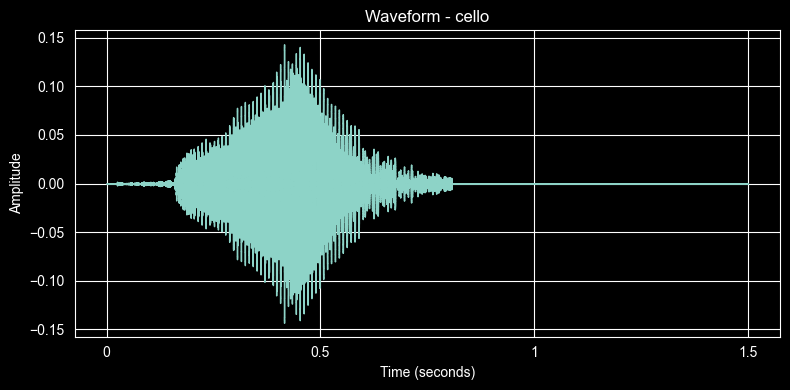

In [8]:
#=============================================================
# 7. 샘플 오디오 waveplot 시각화
#=============================================================

# 파형은 시간축에서 신호 진폭이 어떻게 변하는지 보여주는 가장 기본적인  표현
# onset, silence, envelope 등 거시적 구조를 확인하는 데 유용
plt.figure(figsize=(8,4))
librosa.display.waveshow(y_sample, sr=sr_sample)
plt.title(f"Waveform - {sample_class}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

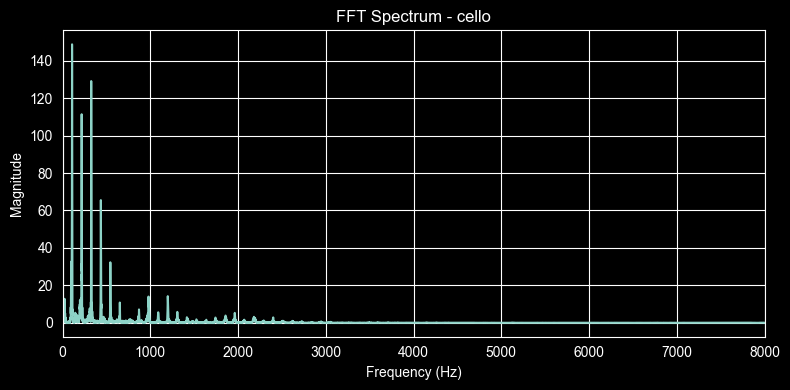

In [9]:
#=============================================================
# 8. 샘플 오디오 FFT 시각화
#=============================================================

# FFT 는 시간영역 신호를 주파수 영역으로 투영하여 어떤 주파수 성분이 강한지 확인
fft_sample = np.fft.fft(y_sample)

# 복소수 푸리에 계수의 절댓값을 취해 magnitude spectrum을 계산
magnitude_sample = np.abs(fft_sample)

# 각 인덱스가 실제 어떤 주파수에 대응하는지 계산
freqs_sample = np.fft.fftfreq(len(magnitude_sample), d=1 / sr_sample)

# 실수 신호 FFT는 음수 주파수 구간이 대칭이므로 양수 영역만 사용
positive_freqs_sample = freqs_sample[: len(freqs_sample)//2]
positive_magnitude_sample = magnitude_sample[: len(magnitude_sample)//2]

# 저주파~중주파 영역을 주로 보기 위해 x축을 적절히 제한
plt.figure(figsize=(8,4))
plt.plot(positive_freqs_sample, positive_magnitude_sample)
plt.title(f"FFT Spectrum - {sample_class}")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0,8000)
plt.tight_layout()
plt.show()

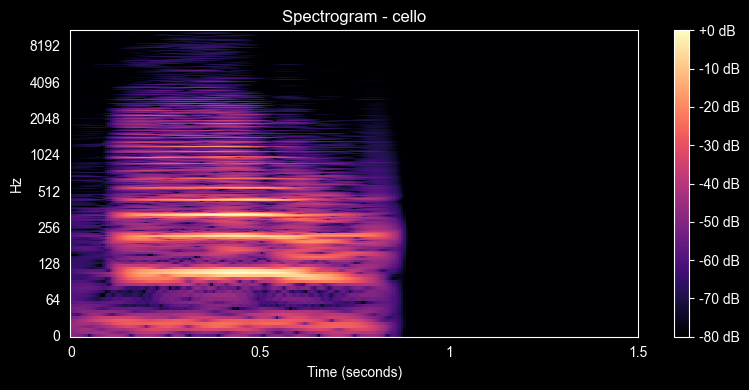

In [10]:
#=============================================================
# 9. 샘플 오디오 STFT Spectrogram 시각화
#=============================================================

# STFT는 짧은 시간 구간별로 FFT를 수행하여 시간-주파수 2차원 표현생성
stft_sample = librosa.stft(y_sample, n_fft=N_FFT, hop_length=HOP_LENGTH)

# 복소수 STFT 결과의 절댓값을 취하여 magnitude spectrogram 생성
spectrogram_sample = np.abs(stft_sample)

# 사람의 청각 및 신호 에너지 해석에 유리하도록 dB 스케일 변환
spectrogram_db_sample = librosa.amplitude_to_db(spectrogram_sample, ref=np.max )

# 로그 주파수축 spectrogram을 그린다.
plt.figure(figsize=(8,4) )
librosa.display.specshow(
    spectrogram_db_sample,
    sr=sr_sample,
    hop_length=HOP_LENGTH,
    x_axis='time',
    y_axis='log',
    cmap='magma'
)
plt.colorbar(format="%+2.0f dB")
plt.title(f"Spectrogram - {sample_class}")
plt.xlabel("Time (seconds)")
plt.tight_layout()
plt.show()

In [11]:
#=============================================================
# 10. Spectrogram 이미지 저장함수
#=============================================================

def save_spectrogram_image(audio_path, save_path, sr = SR, duration = DURATION):
    # 저장 결로의 상위 폴더가 존재하도록 보장
    save_dir = os.path.dirname(save_path)

    # save_path 가 현재 작업 디렉토리 바로 아래 파일일 경우 dirname이 빈 문자열일 수 있다.
    if save_dir != "":
        ensure_directory_exists(save_dir)

    # 오디오를 로드
    y , sr = load_audio_file(audio_path, sr= sr, duration= duration)

    # mel spectrogram을 계산
    mel_spec = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        power=2.0
    )

    # power spectrogram을 dB로 변환 # 소리의 크기를 가지고 색깔의 강조를 주기위해서.
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    fig = plt.figure(figsize=(8,4))

    # 축/ 눈금 없이 순수한 스펙트럼 패턴만 저장되도록 그린다.
    librosa.display.specshow(
        mel_spec_db,
        sr=sr,
        hop_length=HOP_LENGTH,
        x_axis= None,
        y_axis= None,
        cmap='magma'
    )

    # CNN이 의미 없는 축 텍스트를 학습하지 않도록 축을 제거
    plt.axis('off')

    # 저장 시 여백을 최소화
    plt.tight_layout(pad=0)

    # PNG로 저장한다.
    plt.savefig(save_path, bbox_inches='tight', pad_inches=0)

    # 메모리 정리를 위해 figure를 닫는다.
    plt.close(fig)

    # 저장된 이미지를 열어 RGB 변환 후 입력 크기로 통일
    # bbox_inches = 'tight'로 저장하면 실제 픽셀 크기가 매번 조금씩 달라질 수 있으므로 후처리로 정규화
    img = Image.open(save_path).convert("RGB")
    img = img.resize((IMG_WIDTH, IMG_HEIGHT))
    img.save(save_path)

In [12]:
#=============================================================
# 11. 전체 오디오 파일들에 대해서 하나씩 읽어서 전부 변환.
# 전체 오디오 파일 -> Spectrogram .이미지 생성
#=============================================================

# 이전 실행 결과가 남아 있으면 삭제하여 중복/오염을 방지
safe_remove_path(SPEC_DIR)

# spectrogram 루트 폴더 생성
ensure_directory_exists(SPEC_DIR)

print_section_title("스펙트로그램 이미지 생성 시작")

# 클래스별로 모든 mp3를 순회하면서 spectrogram 이미지를 생성
for cls in CLASSES :
    class_audio_dir = os.path.join(INSTRUMENTS_DIR, cls)
    class_spec_dir = os.path.join(SPEC_DIR, cls)

    # 클래스별 spectrogram 저장 포더 생성
    ensure_directory_exists(class_spec_dir)

    #해당 클래스 mp3 목록 가져오기
    audio_files = glob.glob(os.path.join(class_audio_dir, "*.mp3"))

    # 처리 현황을 출력
    print(f"{cls} : {len(audio_files)}개 파일 처리 중 .. ")

    # 각 파일을 spectrogram으로 변환
    for audio_file in audio_files:
        base_name = os.path.splitext(os.path.basename(audio_file))[0]
        save_path = os.path.join(class_spec_dir, f"{base_name}.png")
        save_spectrogram_image(audio_file, save_path)

print("스펙트로그램 이미지 생성 완료")


스펙트로그램 이미지 생성 시작
cello : 100개 파일 처리 중 .. 
flute : 100개 파일 처리 중 .. 
oboe : 100개 파일 처리 중 .. 
sax : 100개 파일 처리 중 .. 
trumpet : 100개 파일 처리 중 .. 
viola : 100개 파일 처리 중 .. 
스펙트로그램 이미지 생성 완료


In [13]:
# ------------------------------------------------------------
# 12. train / val / test 분할 함수
# ------------------------------------------------------------

def split_dataset_to_folders(source_dir, target_dir, classes, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    """
    spectrogram 이미지를 클래스별 train/val/test 폴더 구조로 분할
    """

    # 기존 split 폴더를 삭제
    safe_remove_path(target_dir)

    # 비율의 합이 1인지 검증
    if abs(train_ratio + val_ratio + test_ratio - 1.0) >= 1e-6:
        raise ValueError("[오류] train_ratio + val_ratio + test_ratio의 합은 반드시 1이어야 함")

    for cls in classes:
        class_dir = os.path.join(source_dir, cls)

        # 원본 클래스 이미지가 존재하는지 확인
        if not os.path.exists(class_dir):
            raise FileNotFoundError(f"[오류] spectrogram 클래스 폴더가 없습니다: {class_dir}")

        image_files = glob.glob(os.path.join(class_dir, "*.png"))

        # 클래스별 이미지가 없으면 학습 불가이므로 중단
        if len(image_files) == 0:
            raise ValueError(f"[오류] 클래스 '{cls}'의 spectrogram 이미지가 없습니다.")

        # 무작위 셔플 후 분할
        random.shuffle(image_files)

        n_total = len(image_files)
        n_train = int(n_total * train_ratio)
        n_val = int(n_total * val_ratio)

        train_files = image_files[:n_train]
        val_files = image_files[n_train:n_train + n_val]
        test_files = image_files[n_train + n_val:]

        # split별 폴더를 생성
        for split_name in ["train", "val", "test"]:
            ensure_directory_exists(os.path.join(target_dir, split_name, cls))

        # 복사 보조 함수
        def copy_files(files, split_name):
            for f in files:
                dst = os.path.join(target_dir, split_name, cls, os.path.basename(f))
                shutil.copy2(f, dst)

        copy_files(train_files, "train")
        copy_files(val_files, "val")
        copy_files(test_files, "test")

        print(f"{cls} -> train:{len(train_files)}, val:{len(val_files)}, test:{len(test_files)}")


def validate_split_dataset(target_dir, classes):
    """
    split 이후 각 train/val/test/class 폴더에 최소 1개 이상의 이미지가 있는지 검증한다.
    """
    print_section_title("분할 데이터셋 검증")
    for split_name in ["train", "val", "test"]:
        print(f"[{split_name}]")
        for cls in classes:
            class_dir = os.path.join(target_dir, split_name, cls)
            count = len(glob.glob(os.path.join(class_dir, "*.png")))
            print(f"  {cls}: {count}개")
            if count == 0:
                raise ValueError(
                    f"[오류] {split_name}/{cls} 폴더에 이미지가 없습니다. "
                    f"클래스별 샘플 수가 너무 적거나 분할 비율 조정이 필요합니다."
                )

In [14]:
#=============================================================
# 13. 데이터셋 분할 수행
#=============================================================

print_section_title("train / val / test 분할 시작")
split_dataset_to_folders(SPEC_DIR, SPLIT_DIR, CLASSES, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15)
validate_split_dataset(SPLIT_DIR, CLASSES)
print("데이터 분할 완료")


train / val / test 분할 시작
cello -> train:70, val:15, test:15
flute -> train:70, val:15, test:15
oboe -> train:70, val:15, test:15
sax -> train:70, val:15, test:15
trumpet -> train:70, val:15, test:15
viola -> train:70, val:15, test:15

분할 데이터셋 검증
[train]
  cello: 70개
  flute: 70개
  oboe: 70개
  sax: 70개
  trumpet: 70개
  viola: 70개
[val]
  cello: 15개
  flute: 15개
  oboe: 15개
  sax: 15개
  trumpet: 15개
  viola: 15개
[test]
  cello: 15개
  flute: 15개
  oboe: 15개
  sax: 15개
  trumpet: 15개
  viola: 15개
데이터 분할 완료


In [15]:
#=============================================================
# 14. ImageDataGenerator 설정 // 데이터 어그멘테이션
#=============================================================
#  학습 데이터는 약한 수준의 augmentation을 적용하여 일반화 성능을 높임
# Spectrogram 은 일반 사진과 의미 체계가 다르므로 회전 / 이동 / 확대 범위를 매우 작게 유지
train_datagen = ImageDataGenerator(
    rescale=1./255.0,
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05
)

# 검증 / 테스트 데이터는 모델 평가의 일관성을 위해 정규화 수행
val_test_datagen = ImageDataGenerator(rescale= 1.0/255.0)

# train generator 생성
train_generator = train_datagen.flow_from_directory(
    directory = os.path.join(SPLIT_DIR, "train"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    class_mode = "categorical",
    shuffle = True,
    seed=  SEED
)

# val generator 생성
val_generator = val_test_datagen.flow_from_directory(
    directory = os.path.join(SPLIT_DIR, "val"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    class_mode = "categorical",
    shuffle = False
)

# test generator 생성
test_generator = val_test_datagen.flow_from_directory(
    directory = os.path.join(SPLIT_DIR, "test"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    class_mode = "categorical",
    shuffle = False
)


# 클래스 인덱스 매핑을 출력
print_section_title("클래스 인덱스 매핑")
print(train_generator.class_indices)


# index -> class 이름 역매핑을 미리 만들어 둔다.
# cello : 0 / OBOE : 1 이런 식으로 매핑되어 있음.
# O : cello / 1 : OBOE 이런 식으로 바꿔야 해서 역매핑을 진행.

idx_to_class = {v:k for k, v in train_generator.class_indices.items()}
print("역매핑 : ",idx_to_class)

Found 420 images belonging to 6 classes.
Found 90 images belonging to 6 classes.
Found 90 images belonging to 6 classes.

클래스 인덱스 매핑
{'cello': 0, 'flute': 1, 'oboe': 2, 'sax': 3, 'trumpet': 4, 'viola': 5}
역매핑 :  {0: 'cello', 1: 'flute', 2: 'oboe', 3: 'sax', 4: 'trumpet', 5: 'viola'}


In [16]:
# ------------------------------------------------------------
# 15. CNN 모델 정의
# ------------------------------------------------------------

# 입력 shape는 고정된 spectrogram RGB 이미지 크기
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)

# Sequential 모델 생성
model = models.Sequential()

# Block 1:
# 저수준 edge/texture 패턴을 추출
model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape))
model.add(layers.MaxPooling2D((2, 2)))

# Block 2:
# 더 복잡한 주파수 리지, 하모닉 구조, 시간-주파수 패턴을 학습
model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

# Block 3:
# 중간 수준의 패턴 조합을 표현
model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

# Block 4:
# 클래스 구분력이 높은 상위 수준 특성을 형성
model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

# 2차원 feature map을 1차원 벡터로 변환
model.add(layers.Flatten())

# Dense layer는 학습된 로컬 패턴들을 종합하여 클래스 결정 경계를 형성
model.add(layers.Dense(256, activation='relu'))

# Dropout은 특정 뉴런 의존도를 줄여 과적합방지
model.add(layers.Dropout(0.5))

# 최종 출력층은 6개 클래스 확률 분포를 생성
model.add(layers.Dense(len(CLASSES), activation='softmax'))

# 다중 클래스 분류이므로 categorical_crossentropy를 사용
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 모델 구조를 출력
print_section_title("CNN 모델 구조")
model.summary()


CNN 모델 구조


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,235,270 (50.49 MB)

 Trainable params: 13,235,270 (50.49 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
#=============================================================
# 16. 학습 콜백 설정
#=============================================================

# validation loss 가 일정 epoch 동안 개선되지 않으면 학습을 조기 종료
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# validation accuracy 가 최고일 때 의 모델을 자동 저장
checkpoint  = ModelCheckpoint(
    filepath= BEST_MODEL_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

In [18]:
#=============================================================
# 17. 모델 학습
#=============================================================

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 714ms/step - accuracy: 0.2383 - loss: 1.9055
Epoch 1: val_accuracy improved from None to 0.48889, saving model to ../data/audio/best_instrument_cnn_model.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 24s 809ms/step - accuracy: 0.3095 - loss: 1.7433 - val_accuracy: 0.4889 - val_loss: 1.2153
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 612ms/step - accuracy: 0.4460 - loss: 1.3082
Epoch 2: val_accuracy improved from 0.48889 to 0.50000, saving model to ../data/audio/best_instrument_cnn_model.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 18s 673ms/step - accuracy: 0.4548 - loss: 1.3308 - val_accuracy: 0.5000 - val_loss: 1.2269
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 606ms/step - accuracy: 0.5042 - loss: 1.1457
Epoch 3: val_accuracy improved from 0.50000 to 0.70000, saving model to ../data/audio/best_instrument_cnn_model.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 18s 671ms/step - accuracy: 0.5857 - loss: 1.0262 - val_accuracy: 0.7000 - val_loss: 0.8184
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━

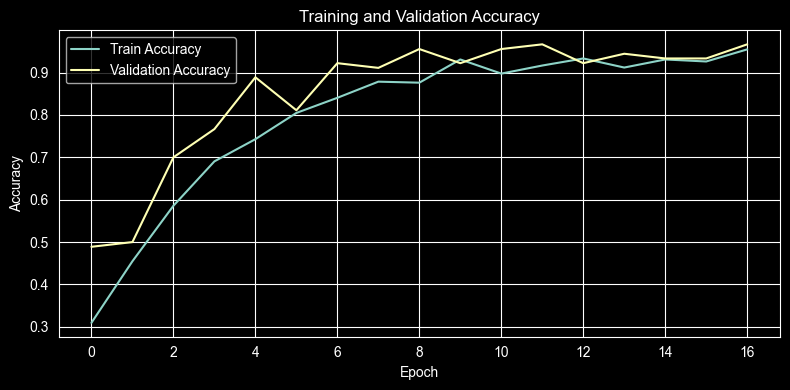

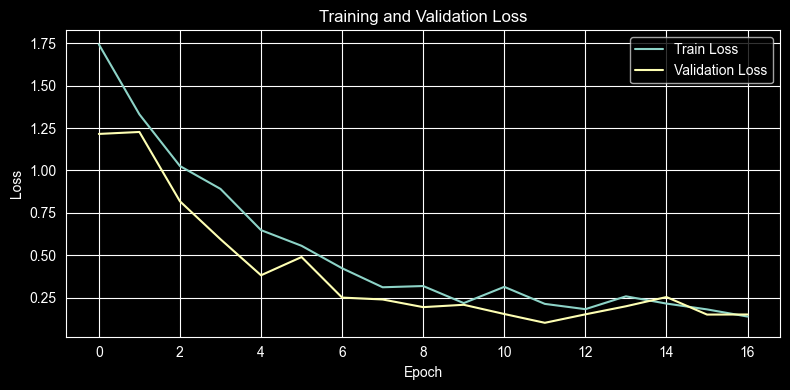

In [19]:
# ------------------------------------------------------------
# 18. 학습 과정 시각화
# ------------------------------------------------------------

plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step

분류 리포트
              precision    recall  f1-score   support

       cello       0.81      0.87      0.84        15
       flute       1.00      0.93      0.97        15
        oboe       0.94      1.00      0.97        15
         sax       1.00      0.87      0.93        15
     trumpet       1.00      1.00      1.00        15
       viola       0.81      0.87      0.84        15

    accuracy                           0.92        90
   macro avg       0.93      0.92      0.92        90
weighted avg       0.93      0.92      0.92        90



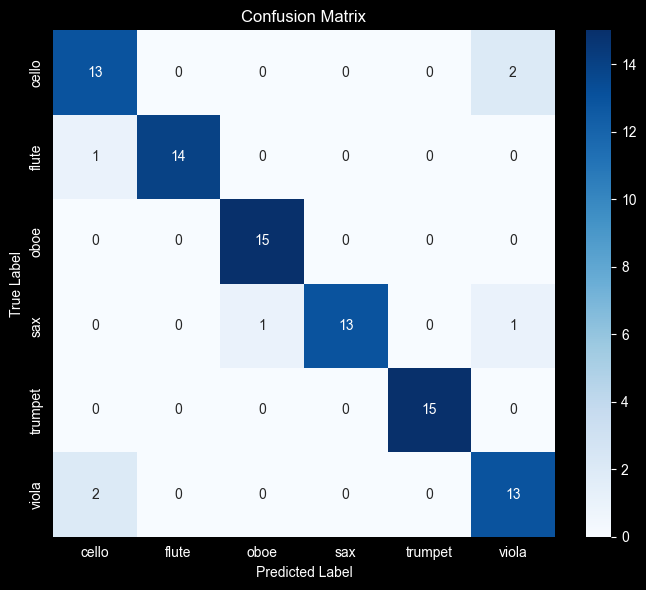

In [20]:
# ------------------------------------------------------------
# 19. 테스트셋 분류 리포트 및 Confusion Matrix
# ------------------------------------------------------------

# 테스트셋 전체에 대해 클래스별 확률을 예측
pred_probs = model.predict(test_generator)

# 가장 큰 확률을 갖는 인덱스를 최종 예측 클래스로 사용
pred_classes = np.argmax(pred_probs, axis=1)

# 실제 정답 라벨
true_classes = test_generator.classes

# 클래스 이름 목록
class_labels = list(test_generator.class_indices.keys())

print_section_title("분류 리포트")
print(classification_report(
    true_classes,
    pred_classes,
    target_names=class_labels,
    zero_division=0
))

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

20~ 21 번은 추론서버에서 하는

In [24]:
# ------------------------------------------------------------
# 20. 예측용 오디오 분석/시각화 함수
# ------------------------------------------------------------

def visualize_audio_analysis(audio_path, predicted_class=None, probs_dict=None):
    """
    신규 입력 오디오에 대해 waveplot, FFT, spectrogram을 순차적으로 시각화
    """

    # 오디오를 로드
    y, sr = load_audio_file(audio_path)

    # 파일명만 표시용으로 추출
    file_name = os.path.basename(audio_path)

    # 1) waveplot 시각화
    plt.figure(figsize=(14, 4))
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"Input Audio Waveform - {file_name}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

    # 2) FFT 시각화
    fft_vals = np.fft.fft(y)
    magnitude = np.abs(fft_vals)
    freqs = np.fft.fftfreq(len(magnitude), d=1 / sr)
    positive_freqs = freqs[:len(freqs) // 2]
    positive_magnitude = magnitude[:len(magnitude) // 2]

    plt.figure(figsize=(14, 4))
    plt.plot(positive_freqs, positive_magnitude)
    plt.title(f"Input Audio FFT Spectrum - {file_name}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.xlim(0, 8000)
    plt.tight_layout()
    plt.show()

    # 3) Spectrogram 시각화
    stft = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH)
    spectrogram = np.abs(stft)
    spectrogram_db = librosa.amplitude_to_db(spectrogram, ref=np.max)

    plt.figure(figsize=(12, 5))
    librosa.display.specshow(
        spectrogram_db,
        sr=sr,
        hop_length=HOP_LENGTH,
        x_axis='time',
        y_axis='log'
    )
    plt.colorbar(format='%+2.0f dB')
    if predicted_class is None:
        plt.title(f"Input Audio Spectrogram - {file_name}")
    else:
        plt.title(f"Input Audio Spectrogram - {file_name}\nPredicted: {predicted_class}")
    plt.tight_layout()
    plt.show()

    # 4) 예측 확률 막대그래프
    if probs_dict is not None:
        probs_df = pd.DataFrame({
            "Class": list(probs_dict.keys()),
            "Probability": list(probs_dict.values())
        }).sort_values("Probability", ascending=False)

        plt.figure(figsize=(8, 4))
        sns.barplot(data=probs_df, x="Class", y="Probability")
        plt.title(f"Prediction Probability - {file_name}")
        plt.xlabel("Instrument Class")
        plt.ylabel("Probability")
        plt.xticks(rotation=30)
        plt.ylim(0, 1.0)
        plt.tight_layout()
        plt.show()

In [25]:
# ------------------------------------------------------------
# 21. 신규 오디오 예측 함수
# ------------------------------------------------------------

def predict_instrument_from_audio_absolute_path(audio_path, model, class_indices, save_temp_image=False):

    """
    절대경로로 지정한 신규 오디오 파일을 읽어와 CNN으로 예측한다.

    기능:
    - 입력 파일 유효성 검사
    - spectrogram 임시 이미지 생성
    - 모델 추론
    - 예측 클래스 및 확률 반환
    - 입력 오디오 waveplot / FFT / spectrogram / 확률 시각화 수행
    """

    # 입력값 타입 검증
    if not isinstance(audio_path, str):
        raise TypeError("[오류] audio_path는 문자열이어야 합니다.")

    # 절대경로인지 확인한다. 사용자 요청 조건을 강제하기 위한 검증.
    if not os.path.isabs(audio_path):
        raise ValueError(f"[오류] 신규 오디오 예측 경로는 절대경로여야 합니다: {audio_path}")

    # 실제 파일 존재 여부 확인
    if not os.path.exists(audio_path):
        raise FileNotFoundError(f"[오류] 신규 예측용 오디오 파일이 존재하지 않습니다: {audio_path}")

    # 모델 유효성 확인
    if model is None:
        raise ValueError("[오류] 학습된 모델이 없습니다.")

    # 클래스 인덱스 매핑 확인
    if not isinstance(class_indices, dict) or len(class_indices) == 0:
        raise ValueError("[오류] class_indices가 비어 있거나 유효하지 않습니다.")

    # 임시 spectrogram 이미지가 남아 있으면 삭제
    if os.path.exists(TEMP_PREDICT_IMAGE_PATH):
        os.remove(TEMP_PREDICT_IMAGE_PATH)

    # 신규 오디오를 spectrogram 이미지로 변환
    save_spectrogram_image(audio_path, TEMP_PREDICT_IMAGE_PATH)

    # 임시 이미지가 실제 생성되었는지 확인
    if not os.path.exists(TEMP_PREDICT_IMAGE_PATH):
        raise FileNotFoundError("[오류] 예측용 임시 spectrogram 이미지 생성에 실패했습니다.")

    # 저장된 이미지를 열어 RGB 변환
    img = Image.open(TEMP_PREDICT_IMAGE_PATH).convert("RGB")

    # 모델 입력 크기로 리사이즈
    img = img.resize((IMG_WIDTH, IMG_HEIGHT))

    # numpy 배열로 변환 후 0~1 범위로 정규화
    img_array = np.array(img).astype("float32") / 255.0

    # (H, W, C) -> (1, H, W, C)로 배치 축을 추가
    img_array = np.expand_dims(img_array, axis=0)

    # 모델 추론을 수행한다.
    probs = model.predict(img_array, verbose=0)[0]

    # 최대 확률 클래스 인덱스를 찾는다.
    pred_idx = int(np.argmax(probs))

    # index -> class 역매핑 생성
    idx_to_class_local = {v: k for k, v in class_indices.items()}

    # 예측 클래스 이름
    predicted_class = idx_to_class_local[pred_idx]

    # 클래스별 확률 dict 생성
    probs_dict = {idx_to_class_local[i]: float(probs[i]) for i in range(len(probs))}

    # 예측용 spectrogram 이미지 자체를 보여준다.
    plt.figure(figsize=(5, 5))
    plt.imshow(Image.open(TEMP_PREDICT_IMAGE_PATH))
    plt.title(f"Prediction Spectrogram\nPredicted: {predicted_class}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # 입력 오디오의 wave/FFT/spectrogram/확률을 함께 시각화
    visualize_audio_analysis(
        audio_path=audio_path,
        predicted_class=predicted_class,
        probs_dict=probs_dict
    )

    # 임시 저장을 원하지 않으면 삭제
    if not save_temp_image and os.path.exists(TEMP_PREDICT_IMAGE_PATH):
        os.remove(TEMP_PREDICT_IMAGE_PATH)

    return predicted_class, probs_dict


신규 오디오 예측 준비
절대경로 입력 예시 :  C:\Users\human\Desktop\workspace\Day10\test_oboe.mp3


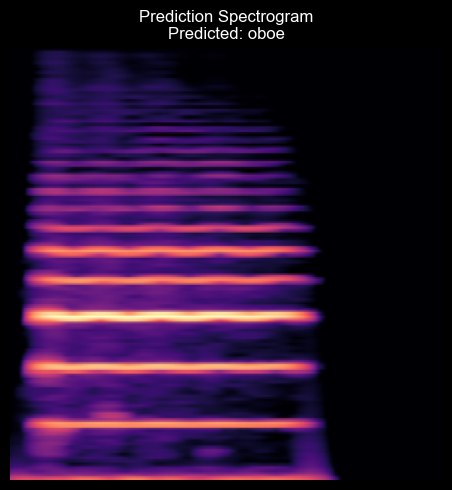

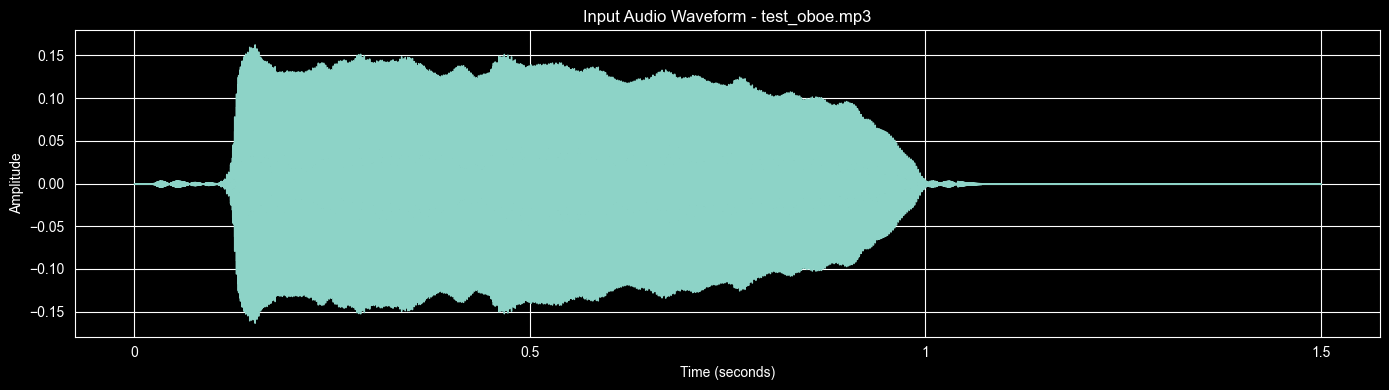

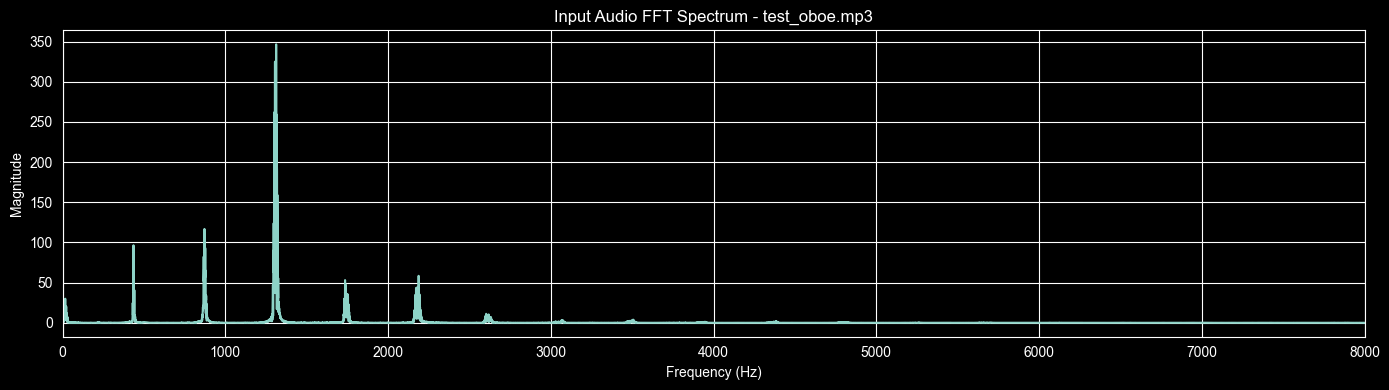

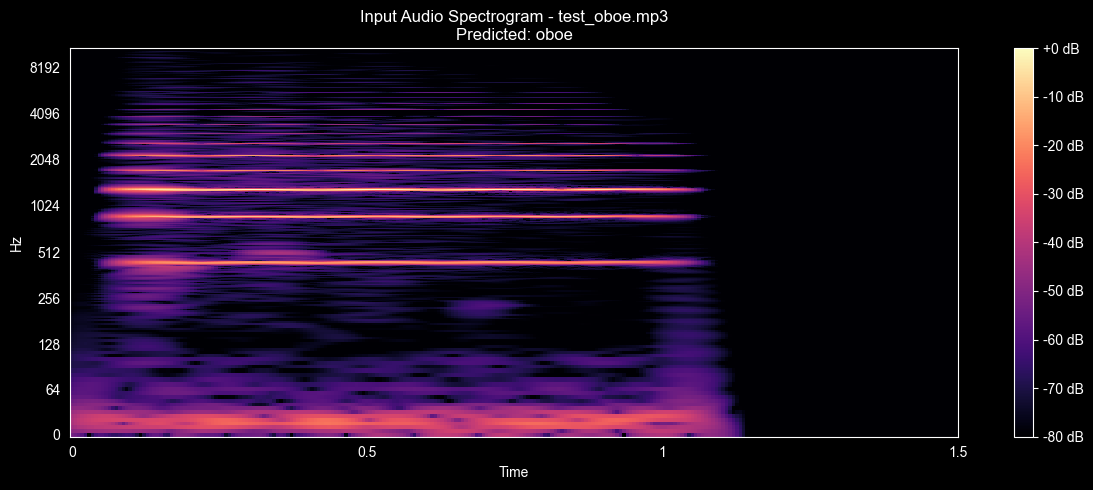

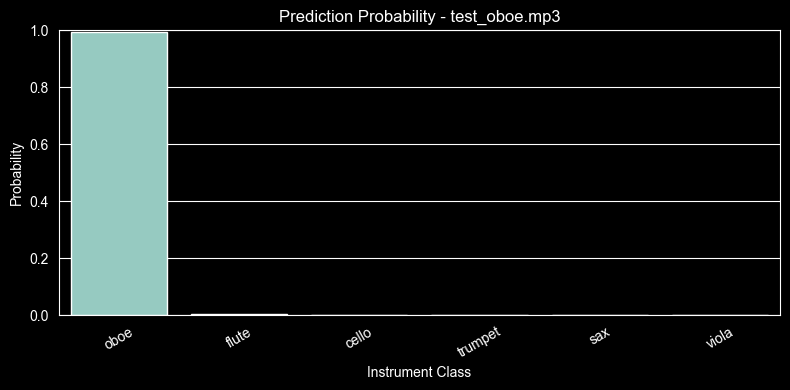


예측 클래스 :  oboe

클래스별 예측 확률 : 
oboe: 0.9956
flute: 0.0038
cello: 0.0004
trumpet: 0.0002
sax: 0.0001
viola: 0.0000


In [26]:
#=============================================================
# 22. 신규 오디오 절대경로
#=============================================================

# 아래 경로는 반드시 사용자의 실제 windows 절대경로로 바꿔서 사용
NEW_AUDIO_ABSOLUTE_PATH = r"C:\Users\human\Desktop\workspace\Day10\test_oboe.mp3"

# 절대경로를 실제 값으로 수정한 뒤 아래 블록을 실행
# 존재하지 않는 예시 경로일 수 있으므로 자동 실행 전에 파일 존재 여부를 먼저 점검
print_section_title("신규 오디오 예측 준비")
print("절대경로 입력 예시 : ", NEW_AUDIO_ABSOLUTE_PATH)

if os.path.exists(NEW_AUDIO_ABSOLUTE_PATH):
    predicted_class , prob_dict = predict_instrument_from_audio_absolute_path(
        audio_path=NEW_AUDIO_ABSOLUTE_PATH,
        model = model,
        class_indices= train_generator.class_indices,
        save_temp_image = False
    )

    print("\n예측 클래스 : ", predicted_class)
    print("\n클래스별 예측 확률 : ")
    for cls, prob in sorted(prob_dict.items(), key = lambda x:x[1], reverse=True):
        print(f"{cls}: {prob:.4f}")
else:
    print("NEW_AUDIO_ABSOLUTE_PATH 를 실제 존재한느 절대경로로 수정한 뒤 예측 블록을 실행하세요.")

지속적인 개발 지속적인 배포 지속적인 운영 하기 위해서 MLOps